# 00 - Data inspection

Every dataset downloaded so far: where it comes from, what it contains, and whether it looks right.
Re-run top to bottom with `uv run jupyter lab` (or in VS Code). Nothing here modifies the data.

| File | Produced by | Source |
|---|---|---|
| `data/processed/universe.csv` | `cae.universe` | derived from prices (spec section 3) |
| `data/raw/prices_daily.parquet` | `cae.universe` | Yahoo Finance via `yfinance` |
| `data/raw/views_daily.parquet` | `cae.views` | Wikimedia REST API (pageviews) |

In [1]:
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cae import config

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 60)
ROOT = config.ROOT

## 1. Provenance

In [2]:
files = {
    "universe.csv": config.PROCESSED / "universe.csv",
    "prices_daily.parquet": config.RAW / "prices_daily.parquet",
    "views_daily.parquet": config.RAW / "views_daily.parquet",
}
rows = []
for name, path in files.items():
    committed = subprocess.run(
        ["git", "log", "-1", "--format=%ad (%h)", "--date=iso", "--", str(path.relative_to(ROOT))],
        cwd=ROOT, capture_output=True, text=True, check=True,
    ).stdout.strip()
    rows.append({"file": name, "size_kB": round(path.stat().st_size / 1024), "first committed / last change": committed})
pd.DataFrame(rows)

,file,size_kB,first committed / last change
0,universe.csv,3,2026-10-03 15:19:15 +0200 (4fb1448)
1,prices_daily.parquet,1662,2026-10-03 15:19:15 +0200 (4fb1448)
2,views_daily.parquet,903,2026-10-03 15:33:33 +0200 (aaa47b2)


In [3]:
pd.Series({
    "Prices: period requested": f"{config.PRICE_START} to {config.PRICE_END}",
    "Prices: fields": "Close (split-adjusted), Adj Close (split + dividend adjusted), Volume (shares)",
    "Views: period requested": f"{config.VIEWS_START} to {config.VIEWS_END}",
    "Views: API parameters": "project=en.wikipedia, access=all-access, agent=user, granularity=daily",
    "Universe: inception cutoff": str(config.INCEPTION_CUTOFF),
    "Universe: liquidity window": f"{config.LIQUIDITY_WINDOW[0]} to {config.LIQUIDITY_WINDOW[1]}",
    "Universe: min median dollar volume": f"${config.MIN_MEDIAN_DOLLAR_VOLUME:,.0f}",
}, name="value").to_frame()

,value
Prices: period requested,2014-07-01 to 2026-10-02
Prices: fields,"Close (split-adjusted), Adj Close (split + div..."
Views: period requested,2015-07-01 to 2026-09-30
Views: API parameters,"project=en.wikipedia, access=all-access, agent..."
Universe: inception cutoff,2015-07-01
Universe: liquidity window,2014-07-01 to 2015-06-30
Universe: min median dollar volume,"$5,000,000"


## 2. Universe (`universe.csv`)

In [4]:
universe = pd.read_csv(config.PROCESSED / "universe.csv")
universe.sort_values("median_dollar_volume_2014_15", ascending=False).reset_index(drop=True)

,ticker,wiki_title,emerging,first_price,last_price,median_dollar_volume_2014_15,included,exclusion_reason
0,EWZ,Brazil,True,2014-07-01,2026-10-02,668490861,True,NaN
1,EWJ,Japan,False,2014-07-01,2026-10-02,331453186,True,NaN
2,EWY,South_Korea,True,2014-07-01,2026-10-02,135215786,True,NaN
3,EWW,Mexico,True,2014-07-01,2026-10-02,125453794,True,NaN
4,EWG,Germany,False,2014-07-01,2026-10-02,123966847,True,NaN
5,EWT,Taiwan,True,2014-07-01,2026-10-02,103553000,True,NaN
6,EWH,Hong_Kong,False,2014-07-01,2026-10-02,55226287,True,NaN
7,EWU,United_Kingdom,False,2014-07-01,2026-10-02,44482149,True,NaN
8,EWA,Australia,False,2014-07-01,2026-10-02,41182029,True,NaN
9,EWC,Canada,False,2014-07-01,2026-10-02,40490420,True,NaN


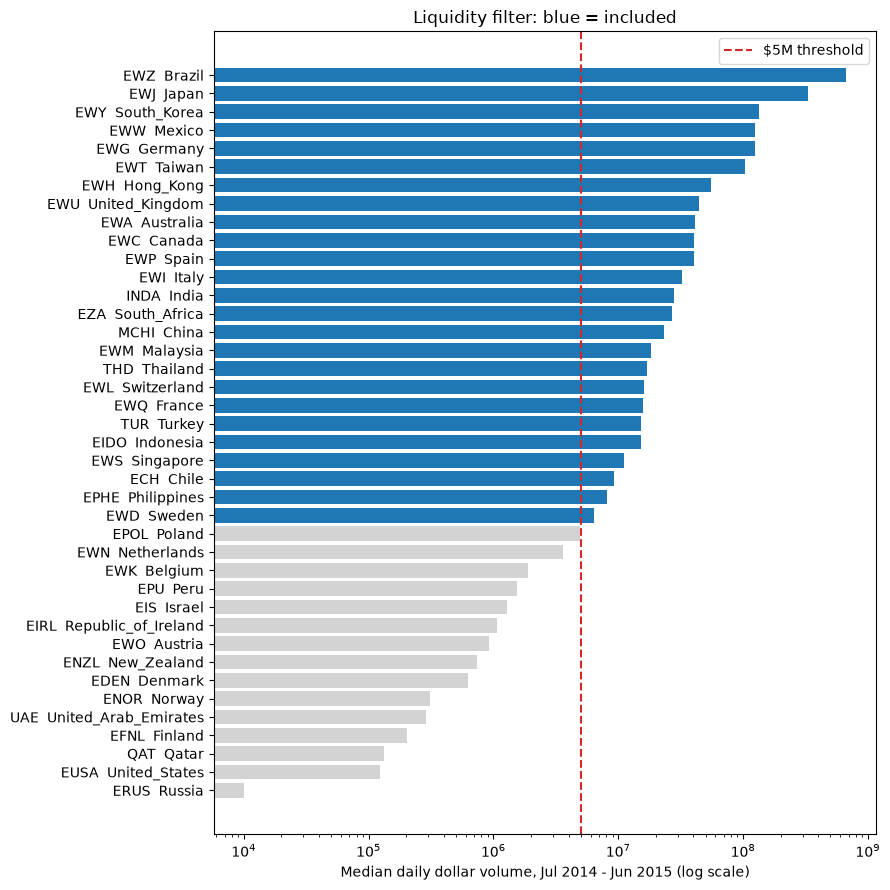

In [5]:
u = universe.sort_values("median_dollar_volume_2014_15")
fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(u["ticker"] + "  " + u["wiki_title"], u["median_dollar_volume_2014_15"].clip(lower=1e4),
        color=np.where(u["included"], "tab:blue", "lightgray"))
ax.axvline(config.MIN_MEDIAN_DOLLAR_VOLUME, color="tab:red", ls="--", label="$5M threshold")
ax.set_xscale("log"); ax.set_xlabel("Median daily dollar volume, Jul 2014 - Jun 2015 (log scale)")
ax.set_title("Liquidity filter: blue = included"); ax.legend(); plt.tight_layout()

In [6]:
included = universe.loc[universe["included"]]
print(f"Included: {len(included)}  (developed {int((~included['emerging']).sum())}, emerging {int(included['emerging'].sum())})")
universe.loc[~universe["included"], ["ticker", "wiki_title", "median_dollar_volume_2014_15", "exclusion_reason"]]

Included: 25  (developed 12, emerging 13)


,ticker,wiki_title,median_dollar_volume_2014_15,exclusion_reason
1,EWO,Austria,912836,below liquidity threshold
2,EWK,Belgium,1894657,below liquidity threshold
7,EDEN,Denmark,630073,below liquidity threshold
8,EFNL,Finland,204447,below liquidity threshold
14,EIRL,Republic_of_Ireland,1060339,below liquidity threshold
15,EIS,Israel,1294923,below liquidity threshold
20,EWN,Netherlands,3605121,below liquidity threshold
21,ENZL,New_Zealand,742460,below liquidity threshold
22,ENOR,Norway,311617,below liquidity threshold
23,EPU,Peru,1539978,below liquidity threshold


## 3. Prices (`prices_daily.parquet`)

In [7]:
prices = pd.read_parquet(config.RAW / "prices_daily.parquet")
print(prices.dtypes, "\n")
print(f"{len(prices):,} rows, {prices['ticker'].nunique()} tickers, {prices['date'].min().date()} to {prices['date'].max().date()}")
prices.head(10)

date         datetime64[us]
ticker                  str
close               float64
adj_close           float64
volume              float64
dtype: object 

123,320 rows, 40 tickers, 2014-07-01 to 2026-10-02


,date,ticker,close,adj_close,volume
0,2014-07-01,ECH,45.540001,32.138214,135600.0
1,2014-07-02,ECH,45.740002,32.279346,248800.0
2,2014-07-03,ECH,46.080002,32.519291,65200.0
3,2014-07-07,ECH,45.750000,32.286415,140200.0
4,2014-07-08,ECH,45.869999,32.371090,224800.0
5,2014-07-09,ECH,46.680000,32.942730,528400.0
6,2014-07-10,ECH,46.590000,32.879204,218800.0
7,2014-07-11,ECH,46.669998,32.935654,597800.0
8,2014-07-14,ECH,46.619999,32.900379,378000.0
9,2014-07-15,ECH,46.419998,32.759239,83100.0


In [8]:
# Keep only the ETFs used in the study (+ UUP).
keep = [*included["ticker"], config.USD_ETF]
p = prices[prices["ticker"].isin(keep)]
adj = p.pivot(index="date", columns="ticker", values="adj_close")

# A "missing day" = a date where at least 90% of the other ETFs have a price but this one does not.
trading_days = adj.index[adj.notna().mean(axis=1) >= 0.9]
summary = p.groupby("ticker").agg(
    first=("date", "min"), last=("date", "max"), days=("date", "size"),
    zero_volume_days=("volume", lambda v: int((v == 0).sum())),
    median_dollar_volume=("close", lambda c: float((c * p.loc[c.index, "volume"]).median())),
)
summary["missing_days"] = adj.loc[trading_days].isna().sum()
summary["adj/close first day"] = (p.groupby("ticker").first()["adj_close"] / p.groupby("ticker").first()["close"]).round(3)
summary["median_dollar_volume"] = (summary["median_dollar_volume"] / 1e6).round(1).astype(str) + "M"
summary

,first,last,days,zero_volume_days,median_dollar_volume,missing_days,adj/close first day
ticker,,,,,,,
ECH,2014-07-01,2026-10-02,3083,0,12.0M,0,0.706
EIDO,2014-07-01,2026-10-02,3083,0,14.0M,0,0.764
EPHE,2014-07-01,2026-10-02,3083,0,4.4M,0,0.859
EWA,2014-07-01,2026-10-02,3083,0,49.0M,0,0.600
EWC,2014-07-01,2026-10-02,3083,0,67.6M,0,0.779
EWD,2014-07-01,2026-10-02,3083,0,7.4M,0,0.670
EWG,2014-07-01,2026-10-02,3083,0,89.3M,0,0.756
EWH,2014-07-01,2026-10-02,3083,0,74.1M,0,0.673
EWI,2014-07-01,2026-10-02,3083,0,19.6M,0,0.681


`adj/close first day` < 1 is expected: adjusted prices are scaled down in the past so that dividends
count as reinvested. The lower the ratio, the more dividends the ETF paid since 2014.

In [9]:
# Largest absolute daily moves (adjusted). Check they match real events, not data errors.
ret = adj.pct_change(fill_method=None)
big = ret.stack().rename("return").reset_index()
big = big.reindex(big["return"].abs().sort_values(ascending=False).index).head(15)
big["return"] = (big["return"] * 100).round(1).astype(str) + "%"
big

,date,ticker,return
37355,2020-03-16,EWZ,-23.1%
48956,2021-12-20,TUR,21.2%
50488,2022-03-16,MCHI,20.9%
37338,2020-03-16,EPHE,-19.4%
37286,2020-03-12,EPHE,-19.0%
44016,2021-03-22,TUR,-18.9%
37329,2020-03-13,EWZ,17.6%
37307,2020-03-12,THD,-17.2%
37303,2020-03-12,EWZ,-16.6%
18895,2017-05-18,EWZ,-16.3%


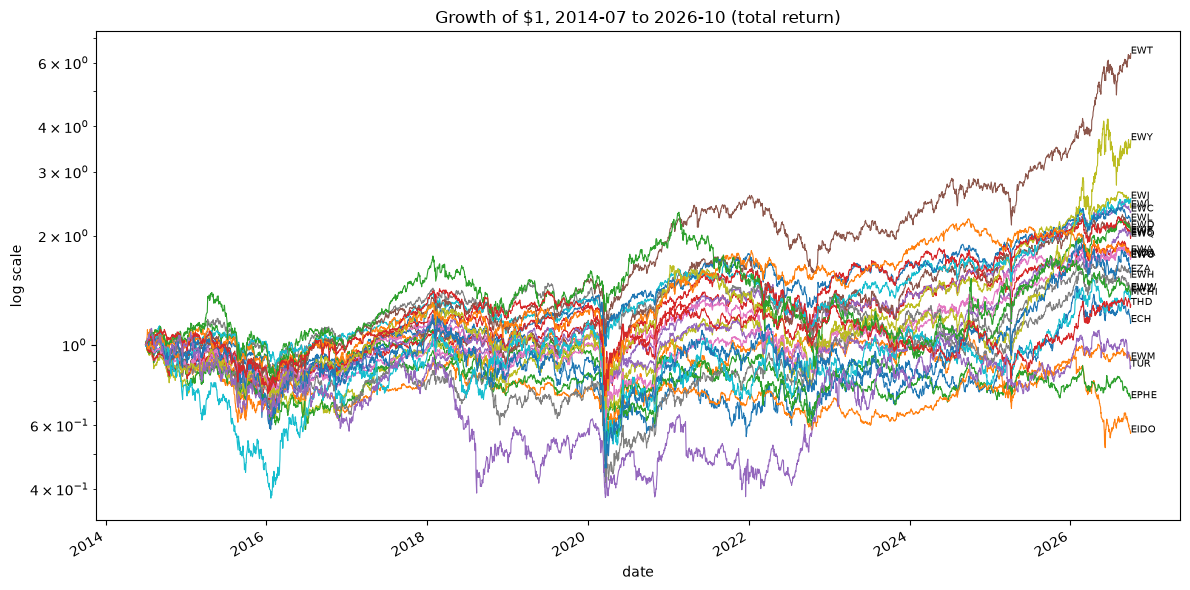

In [10]:
# Growth of $1 (adjusted close, dividends reinvested), log scale.
norm = adj.drop(columns=config.USD_ETF).div(adj.drop(columns=config.USD_ETF).bfill().iloc[0])
fig, ax = plt.subplots(figsize=(12, 6))
norm.plot(ax=ax, legend=False, lw=0.8, logy=True)
for t in norm.columns:
    ax.annotate(t, (norm.index[-1], norm[t].iloc[-1]), fontsize=7)
ax.set_title("Growth of $1, 2014-07 to 2026-10 (total return)"); ax.set_ylabel("log scale")
plt.tight_layout()

In [11]:
# Spot-check any price against Yahoo: open the link and compare the Adj Close for that date.
ticker, day = "EWJ", "2020-03-16"
row = p[(p["ticker"] == ticker) & (p["date"] == day)]
print(f"https://finance.yahoo.com/quote/{ticker}/history/")
row

https://finance.yahoo.com/quote/EWJ/history/


,date,ticker,close,adj_close,volume
56930,2020-03-16,EWJ,43.220001,37.648056,9191600.0


## 4. Wikipedia views (`views_daily.parquet`)

In [12]:
views = pd.read_parquet(config.RAW / "views_daily.parquet")
print(views.dtypes, "\n")
print(f"{len(views):,} rows, {views['title'].nunique()} pages, {views['date'].min().date()} to {views['date'].max().date()}")
print(views.groupby("group")["title"].nunique().rename("pages"))
views.head(10)

date     datetime64[us]
title               str
group               str
views             int64
dtype: object 

221,940 rows, 54 pages, 2015-07-01 to 2026-09-30
group
country    25
economy    25
fear        4
Name: pages, dtype: int64


,date,title,group,views
0,2015-07-01,Australia,country,17714
1,2015-07-02,Australia,country,19612
2,2015-07-03,Australia,country,16584
3,2015-07-04,Australia,country,16568
4,2015-07-05,Australia,country,17644
5,2015-07-06,Australia,country,18632
6,2015-07-07,Australia,country,18115
7,2015-07-08,Australia,country,17686
8,2015-07-09,Australia,country,18273
9,2015-07-10,Australia,country,16762


In [13]:
expected = pd.date_range(config.VIEWS_START, config.VIEWS_END, freq="D")
vsum = views.groupby(["group", "title"]).agg(
    days=("date", "size"), median_daily=("views", "median"),
    min_daily=("views", "min"), max_daily=("views", "max"),
)
vsum["missing_days"] = len(expected) - vsum["days"]
vsum["max/median"] = (vsum["max_daily"] / vsum["median_daily"]).round(1)
vsum

days  median_daily  min_daily  max_daily  missing_days  max/median
group   title                                                                                            
country Australia                      4110       17457.0       9291     548552             0        31.4
        Brazil                         4110        9845.5       6235     164451             0        16.7
        Canada                         4110       18179.5       9445    1078327             0        59.3
        Chile                          4110        4767.0       2993      38584             0         8.1
        China                          4110       18594.0      10400     143195             0         7.7
        France                         4110       12531.0       7116     112763             0         9.0
        Germany                        4110       15208.5       8235      45485             0         3.0
        Hong_Kong                      4110       10478.0       6393     130724             0        12.5
        India                          4110       30958.0      13588     327180             0        10.6
        Indonesia                      4110       10647.5       6873     302934             0        28.5
        Italy                          4110       10150.0       5933     123987             0        12.2
        Japan                          4110       15629.5       9042     101880             0         6.5
        Malaysia                       4110        8825.0       5368      55074             0         6.2
        Mexico                         4110        9906.5       5565      59097             0         6.0
        Philippines                    4110       12513.0       7174      41160             0         3.3
        Singapore                      4110       15368.0       8780     169672             0        11.0
        South_Africa                   4110       11363.0       5918      38532             0         3.4
        South_Korea                    4110        8989.5       5007     122440             0        13.6
        Spain                          4110        9998.0       6303     158662             0        15.9
        Sweden                         4110        8915.0       4703      45262             0         5.1
        Switzerland                    4110       10521.0       5468     105697             0        10.0
        Taiwan                         4110       11112.0       6901     322353             0        29.0
        Thailand                       4110        8389.5       4819     302012             0        36.0
        Turkey                         4110       11996.5       7340     198341             0        16.5
        United_Kingdom                 4110       24124.0      13658     396891             0        16.5
economy Economy_of_Australia           4110         792.0        310       2692             0         3.4
        Economy_of_Brazil              4110         611.0        234       3252             0         5.3
        Economy_of_Canada              4110         855.0        391      15263             0        17.9
        Economy_of_Chile               4110         278.0        102      39729             0       142.9
        Economy_of_China               4110        1898.0        870       6843             0         3.6
        Economy_of_France              4110         611.5        205       6089             0        10.0
        Economy_of_Germany             4110        1013.0        464      33766             0        33.3
        Economy_of_Hong_Kong           4110         300.0        130       4325             0        14.4
        Economy_of_India               4110        6022.0       1896      40029             0         6.6
        Economy_of_Indonesia           4110         581.0        208       8953             0        15.4
        Economy_of_Italy               4110         601.0        259       5556             0         9.2
        Eco

In [14]:
# Top 3 spike days per country page. They should match real news events.
c = views[views["group"] == "country"]
top = c.sort_values("views", ascending=False).groupby("title").head(3)
top.assign(date=top["date"].dt.date).sort_values(["title", "views"], ascending=[True, False])[["title", "date", "views"]]

,title,date,views
3239,Australia,2024-05-13,548552
3238,Australia,2024-05-12,225318
3240,Australia,2024-05-14,189938
4512,Brazil,2016-08-06,164451
6813,Brazil,2022-11-24,110698
...,...,...,...
97308,Turkey,2023-02-07,170579
97307,Turkey,2023-02-06,154721
98999,United_Kingdom,2016-06-24,396891
101267,United_Kingdom,2022-09-09,230791


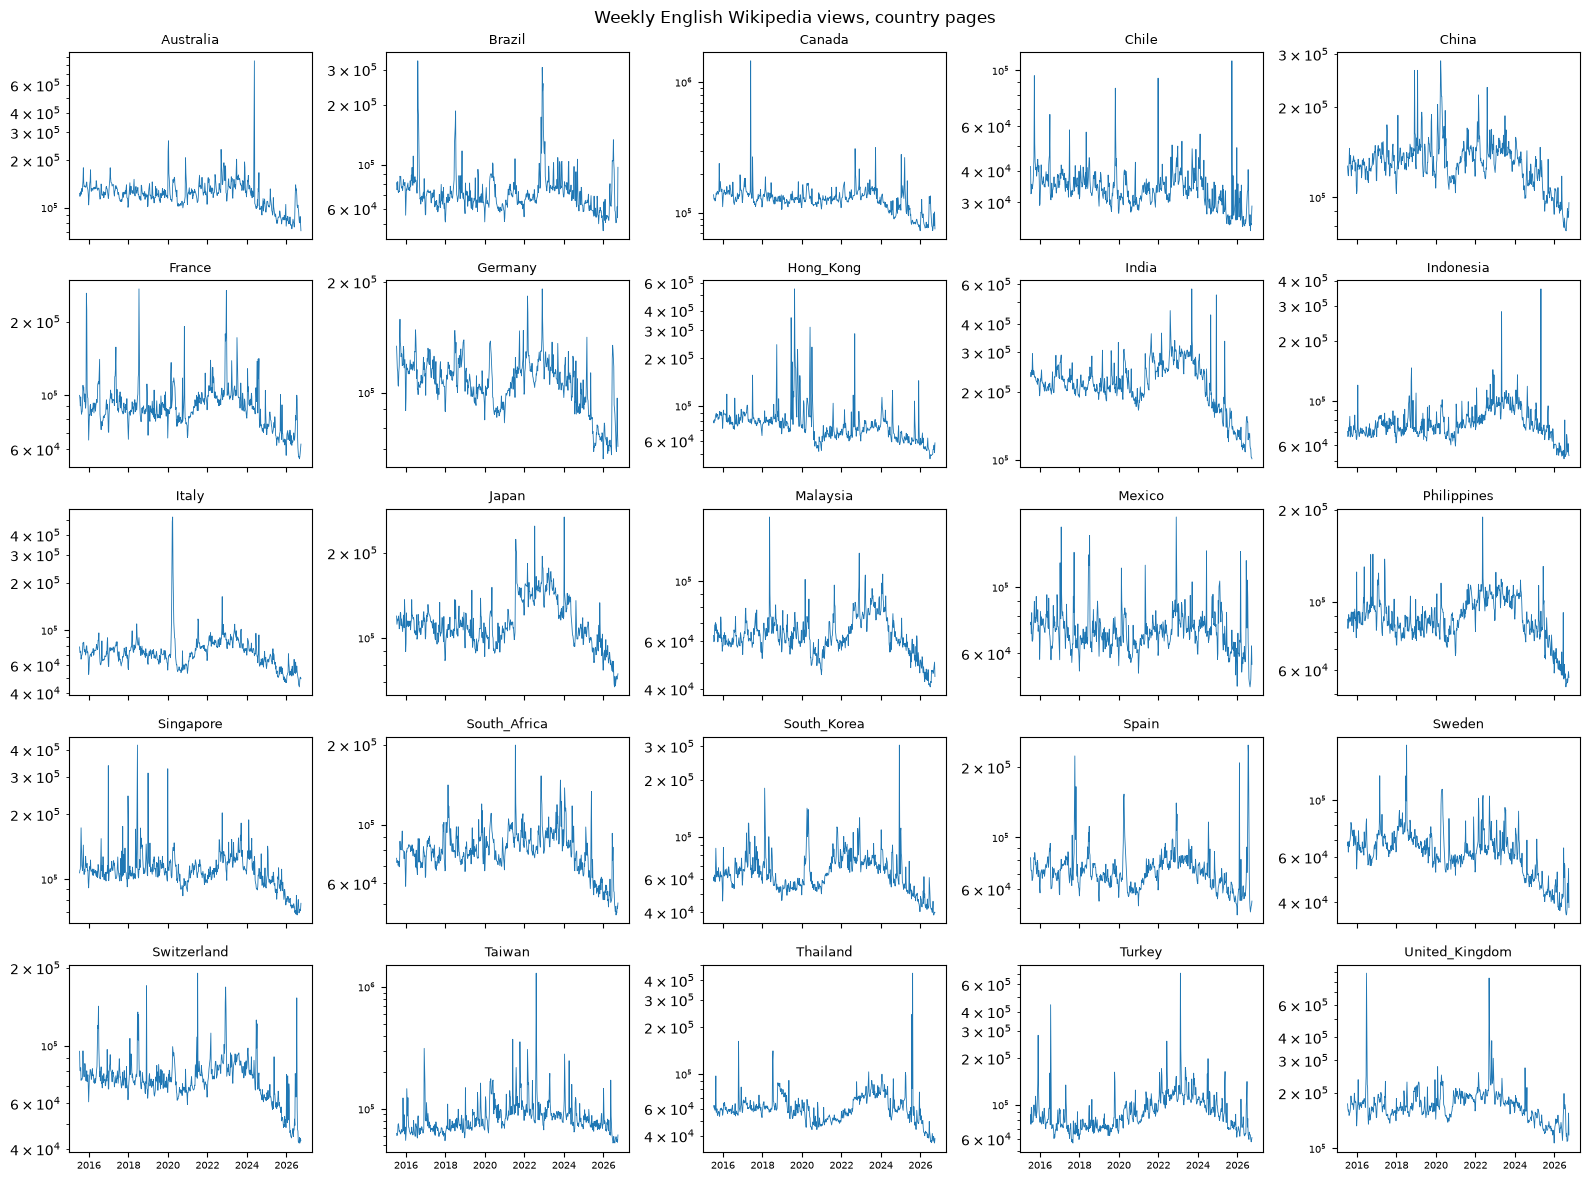

In [18]:
# Weekly views, country pages (small multiples, log scale).
# Weeks run Monday-Sunday; the last week (28-30 Sep 2026) has only 3 days and is dropped,
# otherwise it shows as a fake collapse at the end of every line.
def full_weeks(df):
    g = df.set_index("date").groupby("title")["views"].resample("W-SUN")
    total, days = g.sum().unstack(0), g.size().unstack(0)
    return total[days.eq(7).all(axis=1)]

weekly = full_weeks(c)
fig, axes = plt.subplots(5, 5, figsize=(16, 12), sharex=True)
for ax, t in zip(axes.flat, weekly.columns):
    ax.plot(weekly.index, weekly[t], lw=0.6); ax.set_yscale("log"); ax.set_title(t, fontsize=9)
    ax.tick_params(labelsize=7)
fig.suptitle("Weekly English Wikipedia views, country pages"); plt.tight_layout()

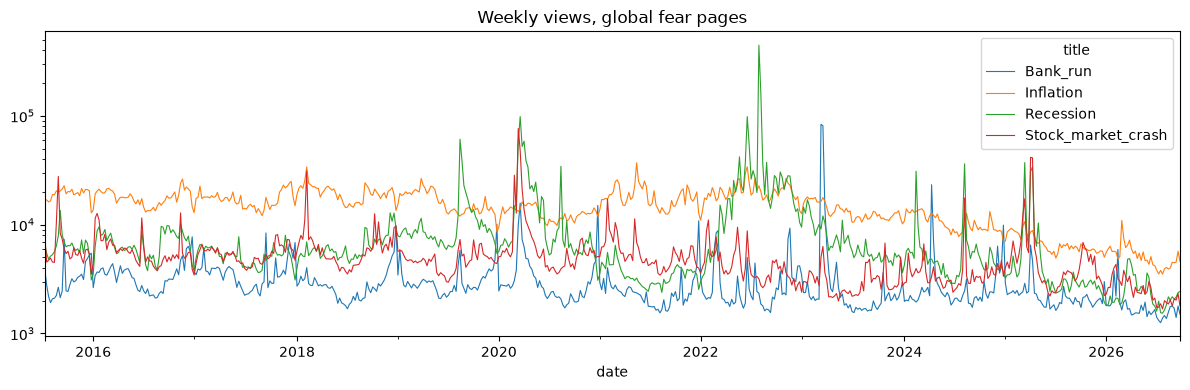

In [16]:
# Global fear pages (R8).
f = full_weeks(views[views["group"] == "fear"])
f.plot(figsize=(12, 4), logy=True, lw=0.8, title="Weekly views, global fear pages"); plt.tight_layout()

In [17]:
# Spot-check any value against the source: this URL returns the raw API answer for that page and day.
title, day = "Turkey", "2023-02-06"   # earthquake day
print(f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/{title}/daily/{day.replace('-', '')}/{day.replace('-', '')}")
views[(views["title"] == title) & (views["date"] == day)]

https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/Turkey/daily/20230206/20230206


,date,title,group,views
97307,2023-02-06,Turkey,country,154721
